# **XGBoost**
## **Predição de Intenção de Compra**

### **Contexto**

A previsão da intenção de compra em sites de e-commerce é um recurso estratégico para aprimorar a experiência do cliente e direcionar ações de marketing com maior eficiência. A análise de dados demográficos e econômicos pode revelar padrões associados à probabilidade de compra.

### **Objetivo Geral**

Desenvolver um modelo preditivo para identificar clientes com maior propensão a comprar (variável `Purchased`).

### **Objetivos Específicos**

- Pré-processar os dados: remover variáveis irrelevantes, codificar categóricas e verificar valores faltantes.
- Treinar um classificador XGBoost para predição de `Purchased`.
- Avaliar o desempenho com métricas de classificação e AUC.
- Analisar a importância das variáveis.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
def print_df_overview(df: pd.DataFrame) -> None:
    print("=" * 50)
    print("ANALISE EXPLORATORIA DO DATAFRAME")
    print("=" * 50)
    print(f"\nDIMENSOES: {df.shape[0]} linhas x {df.shape[1]} colunas")
    print("\nTIPOS DE DADOS:")
    print(df.dtypes.to_frame("Tipo").to_markdown())
    print("=" * 50)
    print("VERIFICACAO DE DUPLICATAS E NULOS")
    print(f"Total registros duplicados: {df.duplicated().sum()}")
    print(f"Total de valores nulos: {df.isnull().sum().sum()}")
    display(df.describe())

def encode_gender(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Gender_encoded"] = LabelEncoder().fit_transform(out["Gender"])
    out = out.drop(columns=["Gender"])
    return out[["Age", "AnnualSalary", "Gender_encoded", "Purchased"]]

def plot_corr_and_report(df: pd.DataFrame, target: str = "Purchased") -> pd.DataFrame:
    df_corr = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, square=True, fmt=".3f")
    plt.title("Matriz de Correlacao", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 50)
    print(f"CORRELACAO COM TARGET ({target})")
    print("=" * 50)
    corr_target = df_corr[target].abs().sort_values(ascending=False)
    corr_target = corr_target[corr_target.index != target]
    for var, corr_val in corr_target.items():
        sinal_real = df_corr.loc[var, target]
        sinal = "(+)" if sinal_real > 0 else "(-)" if sinal_real < 0 else "(0)"
        print(f"{var:20} : {corr_val:.4f} {sinal}")
    return df_corr

def evaluate_binary_classifier(y_true, y_prob, threshold: float = 0.5):
    y_pred = (y_prob > threshold).astype(int)
    print(f"Acuracia: {accuracy_score(y_true, y_pred):.4f}")
    print("\nRelatorio de Classificacao:")
    print(classification_report(y_true, y_pred))
    print("Matriz de Confusao:")
    print(confusion_matrix(y_true, y_pred))
    return y_pred

def plot_roc(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    print(f"AUC: {auc:.2f}")
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return auc

def plot_feature_importance(model, feature_names):
    booster = model.get_booster()
    importances = booster.get_score(importance_type="gain")
    feat_imp = pd.DataFrame(list(importances.items()), columns=["feature", "gain"])
    feat_imp = feat_imp.sort_values(by="gain", ascending=False)
    mapping = {f"f{i}": col for i, col in enumerate(feature_names)}
    feat_imp["feature"] = feat_imp["feature"].map(lambda x: mapping.get(x, x))
    print(feat_imp)
    plt.figure(figsize=(10, 5))
    plt.bar(feat_imp["feature"], feat_imp["gain"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Gain")
    plt.title("Importancia das Variaveis (XGBoost)")
    plt.tight_layout()
    plt.show()

### **Carregamento e análise inicial**

In [3]:
dfo = pd.read_csv("../../Base de Dados/CARRO_CLIENTES.csv", delimiter=",")
dfo.drop(columns=["User ID"], inplace=True)
df = dfo.copy()
print_df_overview(df)

ANALISE EXPLORATORIA DO DATAFRAME

DIMENSOES: 1000 linhas x 4 colunas

TIPOS DE DADOS:
|              | Tipo   |
|:-------------|:-------|
| Gender       | str    |
| Age          | int64  |
| AnnualSalary | int64  |
| Purchased    | int64  |
VERIFICACAO DE DUPLICATAS E NULOS
Total registros duplicados: 57
Total de valores nulos: 0


,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


### Comentário sobre duplicatas

Após remover `User ID`, duplicatas em `Gender`, `Age`, `AnnualSalary` e `Purchased` podem representar indivíduos distintos com os mesmos atributos. Com poucas variáveis explicativas, repetições são plausíveis e podem ser mantidas quando coerentes com o contexto do problema.

### Pré-processamento

In [4]:
df = encode_gender(df)
df.head()

,Age,AnnualSalary,Gender_encoded,Purchased
0,35,20000,1,0
1,40,43500,1,0
2,49,74000,1,0
3,40,107500,1,1
4,25,79000,1,0


### Correlação

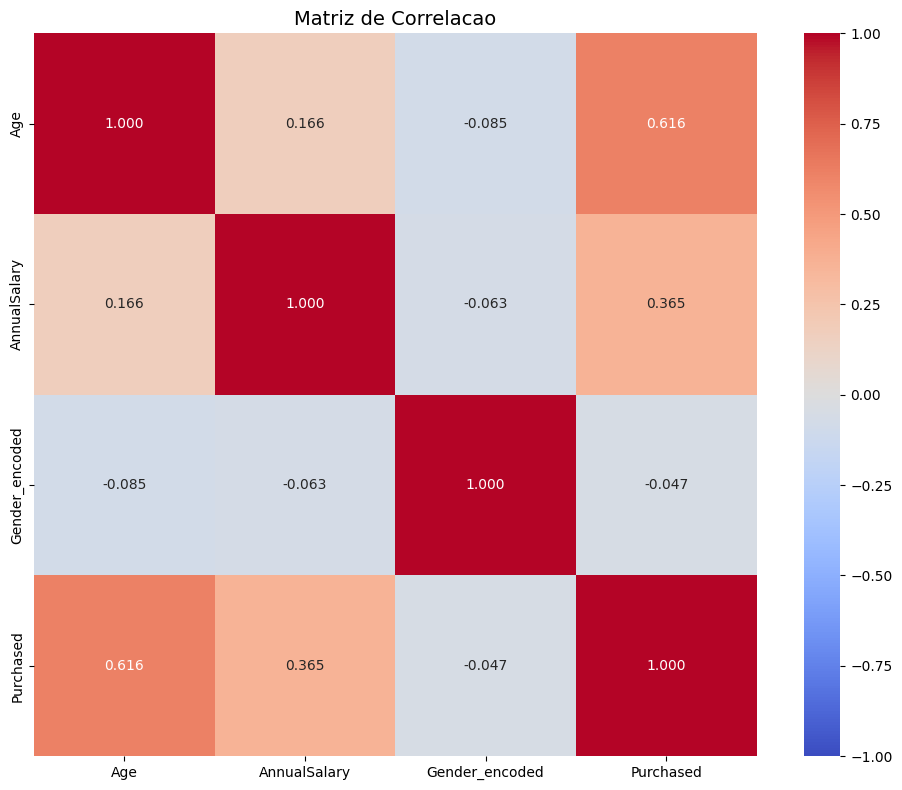


CORRELACAO COM TARGET (Purchased)
Age                  : 0.6160 (+)
AnnualSalary         : 0.3650 (+)
Gender_encoded       : 0.0472 (-)


In [5]:
df_corr = plot_corr_and_report(df, target="Purchased")

### Treino do modelo

In [6]:
X = df.drop("Purchased", axis=1)
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_xgboost = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
model_xgboost.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Avaliação

Acuracia: 0.9000

Relatorio de Classificacao:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       120
           1       0.89      0.85      0.87        80

    accuracy                           0.90       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.90      0.90       200

Matriz de Confusao:
[[112   8]
 [ 12  68]]
AUC: 0.97


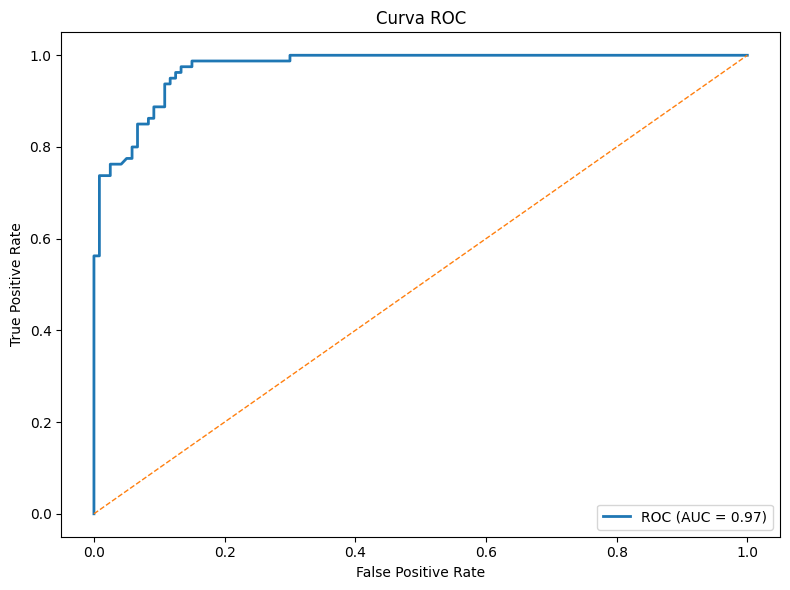

In [7]:
y_pred_prob = model_xgboost.predict_proba(X_test)[:, 1]
y_pred = evaluate_binary_classifier(y_test, y_pred_prob, threshold=0.5)
auc = plot_roc(y_test, y_pred_prob)

### Importância das variáveis

          feature      gain
0             Age  1.771746
1    AnnualSalary  1.108765
2  Gender_encoded  0.435068


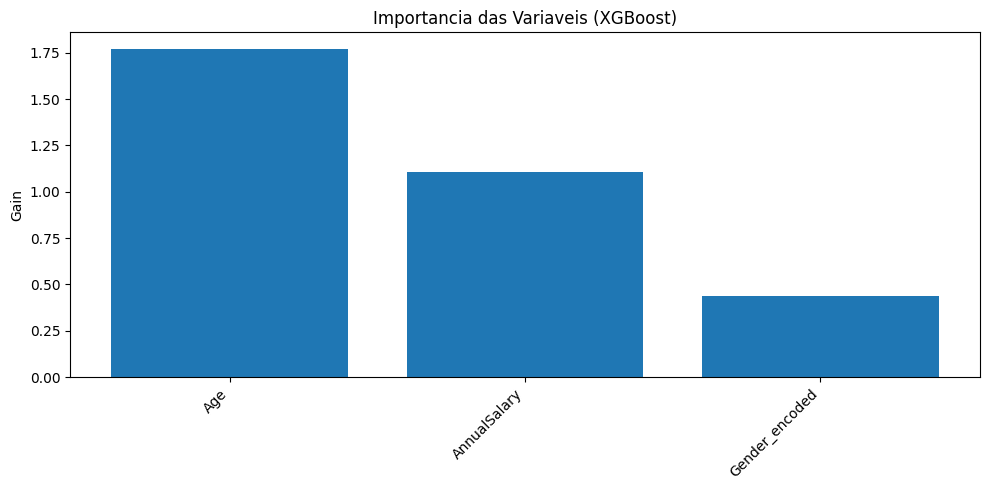

In [8]:
plot_feature_importance(model_xgboost, X.columns)